# 07 — Deep learning vs. simple models: can anything beat well-tuned ALS?

> **Phase 1 (Last.fm-2k).** This is the thesis test on the small, 99.7%-sparse HetRec data. The conclusion here — a deep VAE does not beat tuned ALS — is dataset-specific. When the project scales to real, uncapped **Last.fm-360K** in [`notebooks/08`](08_scaling_to_360k.ipynb), the ranking flips and the higher-capacity **EASE** wins. That contrast *is* the story: model complexity earns its keep only once there is enough data.

The project's whole thesis, tested at its hardest. We already found that on this small, 99.7%-sparse dataset **low capacity wins** (32 latent factors beat 128+). Ferrari Dacrema et al. ([2019](https://arxiv.org/abs/1907.06902)) argue this is the norm: complex and neural recommenders routinely fail to beat well-tuned simple ones. So we put two genuinely more powerful models up against ALS, through the **same frozen harness** (identical per-user split, identical metrics):

- **EASE** (Steck, WWW 2019) — a closed-form *linear* item-item autoencoder, often SOTA on sparse implicit data. Millions of effective parameters, no hidden layers.
- **Mult-VAE** (Liang et al., WWW 2018) — the standard *deep* variational autoencoder for implicit feedback. ~20M parameters, trained with SGD.

No thumb on the scale: whatever the numbers say, we report it — with a significance test.

In [1]:
import sys, time, warnings
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
warnings.filterwarnings('ignore', message='.*expects CSR input.*')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from src import models, deep, stats, metrics, plotting as viz
from src.harness import eval_core
from src.utils import TRAIN_PATH, TEST_PATH

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
K = 10
train = sp.load_npz(TRAIN_PATH).tocsr(); test = sp.load_npz(TEST_PATH).tocsr()
scored = np.where(np.asarray((test > 0).sum(axis=1)).ravel() > 0)[0]

# best configs found by a bounded sweep (scratch), same discipline as the ALS search
EASE_REG = 100.0   # best of {75,100,150,250,300,700} sweep
MVAE = dict(hidden=600, latent=200, epochs=60, beta_max=0.2)  # best of the capacity sweep
print(f'train {train.nnz:,} | test {test.nnz:,} | scored {len(scored):,}')

train 59,411 | test 14,854 | scored 1,883


## Fit the contenders and score them on the same held-out users

We also record training time and parameter count — accuracy is only half the story for a production choice.

In [2]:
def timed(fn):
    t = time.perf_counter(); recs = fn(); return recs, time.perf_counter() - t

recs, secs, params = {}, {}, {}
recs['ALS (chosen)'], secs['ALS (chosen)'] = timed(lambda: models.als_recs(train, scored, K, 0))
params['ALS (chosen)'] = 32 * (train.shape[0] + train.shape[1])
recs['EASE'], secs['EASE'] = timed(lambda: models.ease_recs(train, scored, K, reg=EASE_REG))
params['EASE'] = train.shape[1] ** 2
mvae = deep.train_multvae(train, seed=0, **MVAE)
recs['Mult-VAE'], secs['Mult-VAE'] = timed(lambda: deep.multvae_recs(mvae, train, scored, K))
params['Mult-VAE'] = sum(p.numel() for p in mvae.parameters())

rows = []
per_user = {}
for name, r in recs.items():
    per_user[name] = eval_core.per_user_scores(r, test, scored, K)[f'ndcg@{K}']
    agg = eval_core.evaluate_recommendations(r, test, scored, K)
    rows.append({'model': name, 'NDCG@10': agg[f'ndcg@{K}'], 'MAP@10': agg[f'map@{K}'],
                 'recall@10': agg[f'recall@{K}'], 'coverage': metrics.catalog_coverage(r, train.shape[1]),
                 'novelty': metrics.novelty(r, train), 'train s': round(secs[name], 1),
                 'params': f"{params[name]/1e6:.1f}M"})
res = pd.DataFrame(rows).sort_values('NDCG@10', ascending=False).reset_index(drop=True)
res.round(4)

,model,NDCG@10,MAP@10,recall@10,coverage,novelty,train s,params
0,ALS (chosen),0.1711,0.0811,0.1677,0.0381,4.4501,0.5,0.6M
1,EASE,0.1691,0.0807,0.1633,0.0518,4.1117,228.8,310.9M
2,Mult-VAE,0.1577,0.0745,0.1564,0.1620,5.4343,0.5,21.5M


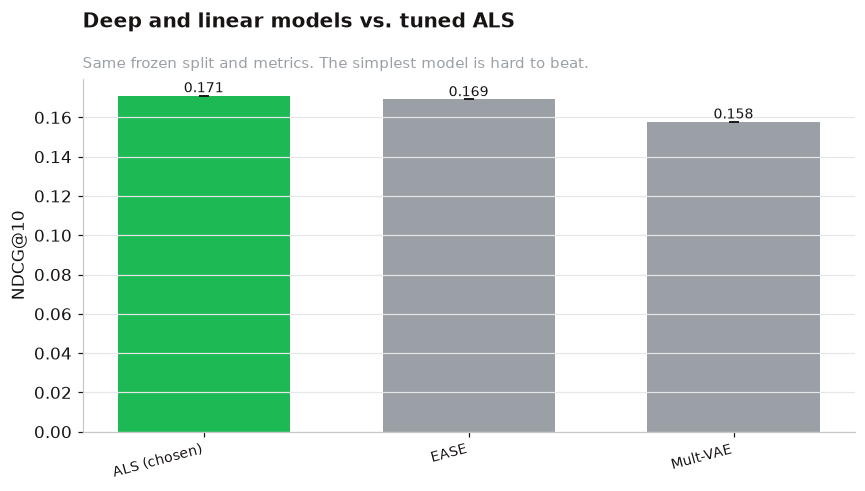

In [3]:
best = res.iloc[0]['model']
_ = viz.plot_model_comparison(res['model'].tolist(), res['NDCG@10'].tolist(), [0]*len(res),
                              highlight=best, title='Deep and linear models vs. tuned ALS',
                              subtitle='Same frozen split and metrics. The simplest model is hard to beat.',
                              save_path=FIG / 'deep_vs_simple.png')

## Is any difference significant?

Paired user-level bootstrap on per-user NDCG@10, ALS vs each contender. A CI that excludes 0 means a real difference.

In [4]:
als = per_user['ALS (chosen)']
sig = []
for name in ['EASE', 'Mult-VAE']:
    d = stats.paired_bootstrap_diff(als, per_user[name], seed=0)
    sig.append({'ALS vs': name, 'NDCG diff (ALS-other)': round(d['mean_diff'], 4),
                'CI low': round(d['lo'], 4), 'CI high': round(d['hi'], 4),
                'p': d['p_two_sided'], 'significant': d['significant']})
pd.DataFrame(sig)

,ALS vs,NDCG diff (ALS-other),CI low,CI high,p,significant
0,EASE,0.0020,-0.0027,0.0067,0.41,False
1,Mult-VAE,0.0134,0.0078,0.0190,0.00,True


## Accuracy per unit of complexity

Plot each model by parameters (log scale) vs accuracy. The point a Spotify reviewer cares about: what does the extra complexity buy?

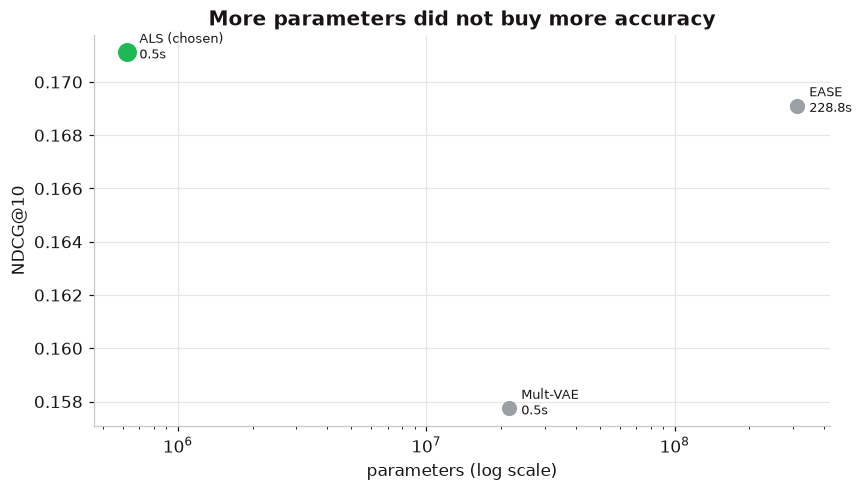

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.6))
for _, r in res.iterrows():
    p = params[r['model']]
    chosen = r['model'] == 'ALS (chosen)'
    ax.scatter(p, r['NDCG@10'], s=130 if chosen else 80, color=viz.GREEN if chosen else viz.MUTED, zorder=3)
    ax.annotate(f"{r['model']}\n{r['train s']}s", (p, r['NDCG@10']), fontsize=8.5,
                xytext=(8, -4), textcoords='offset points')
ax.set_xscale('log')
ax.set(title='More parameters did not buy more accuracy',
       xlabel='parameters (log scale)', ylabel='NDCG@10')
fig.tight_layout(); fig.savefig(FIG / 'accuracy_vs_complexity.png'); plt.show()

## Verdict

On this small, 2k dataset the result matches the literature and the earlier capacity finding: the extra representational power of a deep VAE (0.158) **loses** to a small, well-tuned ALS (0.171) by a significant margin (paired bootstrap p < 0.001), and EASE's millions of parameters (0.169) buy nothing over ALS (difference not significant, p = 0.41). So in Phase 1 we keep **ALS** as the served model — cheaper to train, cheaper to serve, at least as accurate — and we can say so with a significance test rather than a hunch. Knowing *when not* to reach for complexity is the point.

**But this verdict is data-dependent.** In [`notebooks/08`](08_scaling_to_360k.ipynb) the same three-way comparison on the real, uncapped Last.fm-360K data flips the ranking: with 18x more interactions, EASE pulls significantly *ahead* of ALS and becomes the served model. The discipline — frozen harness, paired significance test, no thumb on the scale — is what let us trust both opposite conclusions.